# 🛡️ Cyber Threat Detection — ML Classification
**Australian Government — Australian Signals Directorate (ASD)**

## Policy Context
ASD’s Australian Cyber Security Centre (ACSC) responds to tens of thousands of cyber incidents annually targeting Commonwealth networks. Under the Essential Eight maturity model, agencies must detect and contain threats rapidly. This notebook builds an ML classifier to triage network events as malicious or benign, supporting SOC analysts with automated first-pass screening.

**Synthetic dataset** via `sklearn.make_classification` — 15 features representing network telemetry signals (packet anomaly score, connection duration, bytes transferred, port entropy, geo-mismatch flag, payload signature score, etc.).

| Section | Content |
|---|---|
| 1 | Data Loading & Exploration |
| 2 | Preprocessing & Feature Engineering |
| 3 | Baseline Models (4-model comparison, 3-fold CV) |
| 4 | Hyperparameter Tuning |
| 5 | Feature Importance |
| 6 | Error Analysis |
| 7 | Model Comparison Dashboard |
| 8 | Policy Recommendations |
| 9 | Deployment Readiness Checklist |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='magma')
print('Libraries loaded.')

Libraries loaded.


## 1 — Data Loading & Exploration

In [2]:
X, y = make_classification(n_samples=8000, n_features=15, n_informative=10, n_redundant=3,
                           n_clusters_per_class=3, flip_y=0.06, class_sep=0.9, random_state=58,
                           weights=[0.65, 0.35])
feat_names = ['pkt_anomaly','conn_duration','bytes_in','bytes_out','port_entropy',
              'geo_mismatch','payload_sig','dns_query_rate','failed_logins','priv_escalation',
              'session_count','tls_version','cert_age_days','time_of_day','lateral_move_score']
df = pd.DataFrame(X, columns=feat_names)
df['is_threat'] = y
print(f'Shape: {df.shape}')
print(f'Target distribution:\n{df.is_threat.value_counts(normalize=True).round(3)}')
df.head()

Shape: (8000, 16)
Target distribution:
is_threat
0    0.643
1    0.357
Name: proportion, dtype: float64


,pkt_anomaly,conn_duration,bytes_in,bytes_out,port_entropy,geo_mismatch,payload_sig,dns_query_rate,failed_logins,priv_escalation,session_count,tls_version,cert_age_days,time_of_day,lateral_move_score,is_threat
0,2.192450,0.022718,3.453429,-3.220322,0.457804,-2.306287,-3.894858,-2.032466,2.191942,-9.387269,0.414413,-1.604317,-0.986873,-3.577354,0.243708,0
1,0.241607,0.575990,4.258548,1.799198,-1.901997,-3.052371,6.582576,2.105143,0.176537,-1.297017,1.144273,0.642121,0.990272,3.070625,-0.190100,0
2,0.357103,-1.705682,3.239205,-0.265147,1.633037,-1.566463,11.571417,0.889687,2.069942,0.375060,-3.338504,1.645376,-0.440432,3.310324,1.662183,0
3,0.021641,-0.105456,-1.585511,-0.088293,2.731770,0.319902,-0.540379,-2.989722,2.186153,6.649945,1.234598,0.619422,-0.313499,2.743747,-0.205989,1
4,2.208831,0.456353,-0.438031,-1.652957,-1.792398,-6.317310,-0.635555,1.862961,-2.447695,-5.155731,0.764347,-3.117103,0.980881,1.133346,1.241248,0


In [3]:
df.describe().round(3)

,pkt_anomaly,conn_duration,bytes_in,bytes_out,port_entropy,geo_mismatch,payload_sig,dns_query_rate,failed_logins,priv_escalation,session_count,tls_version,cert_age_days,time_of_day,lateral_move_score,is_threat
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,0.469,-0.023,-0.069,0.314,-0.317,-0.824,0.296,0.286,-0.307,-0.593,0.108,-0.904,-0.005,0.692,-0.314,0.357
std,2.217,0.991,2.149,2.026,1.893,3.933,4.592,1.999,1.976,3.889,1.941,1.941,0.990,1.962,1.932,0.479
min,-8.632,-4.426,-8.447,-7.332,-8.511,-15.229,-18.436,-7.478,-9.008,-14.826,-6.948,-8.797,-3.790,-8.237,-6.858,0.000
25%,-1.036,-0.690,-1.477,-1.092,-1.589,-3.545,-2.680,-1.011,-1.611,-3.131,-1.273,-2.172,-0.677,-0.633,-1.610,0.000
50%,0.454,-0.023,-0.044,0.246,-0.191,-0.877,0.304,0.340,-0.320,-0.615,-0.019,-0.946,-0.001,0.683,-0.319,0.000
75%,1.954,0.639,1.351,1.642,1.013,1.819,3.208,1.647,0.987,1.882,1.392,0.385,0.652,2.025,1.002,1.000
max,8.651,3.328,8.599,9.002,6.416,13.722,16.351,6.855,6.783,17.537,8.968,6.333,3.792,8.634,6.918,1.000


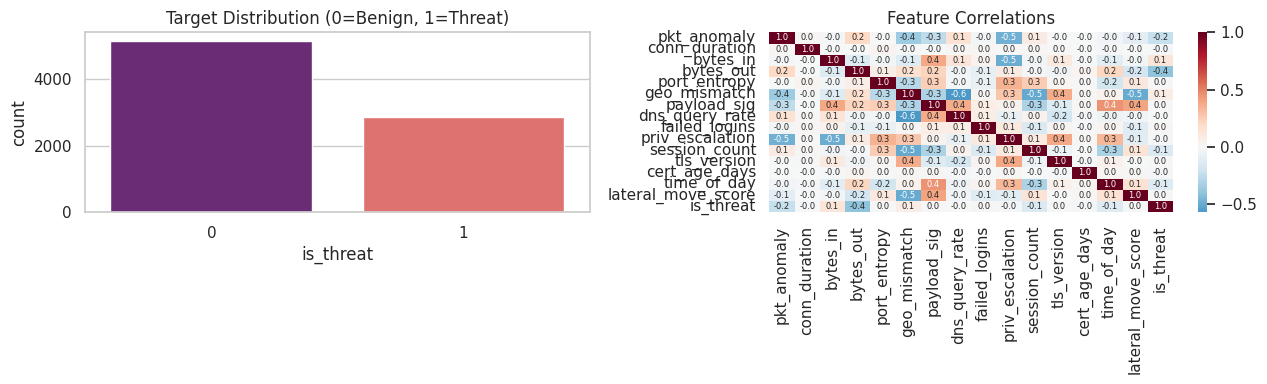

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.countplot(x='is_threat', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Target Distribution (0=Benign, 1=Threat)')
sns.heatmap(df.corr(), cmap='RdBu_r', center=0, ax=axes[1], fmt='.1f',
            annot=True, annot_kws={'size':6}); axes[1].set_title('Feature Correlations')
plt.tight_layout(); plt.show()

## 2 — Preprocessing & Feature Engineering

In [5]:
TARGET = 'is_threat'
FEATURES = [c for c in df.columns if c != TARGET]
X = df[FEATURES]; y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (6400, 15)  Test: (1600, 15)


## 3 — Baseline Models (3-Fold CV)

In [6]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
}
results = {}
for name, m in models.items():
    Xu = X_train_sc if 'Logistic' in name else X_train
    s = cross_val_score(m, Xu, y_train, cv=cv, scoring='roc_auc')
    results[name] = s
    print(f'{name:22s} | AUC: {s.mean():.4f} \u00b1 {s.std():.4f}')

LogisticRegression     | AUC: 0.7879 ± 0.0053
RandomForest           | AUC: 0.9265 ± 0.0034
XGBoost                | AUC: 0.9339 ± 0.0018
LightGBM               | AUC: 0.9356 ± 0.0004


## 4 — Hyperparameter Tuning

In [7]:
param_grid = {'n_estimators': [200, 400], 'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1]}
grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1),
                    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
best = grid.best_estimator_
print(f'Best params: {grid.best_params_}\nBest CV AUC: {grid.best_score_:.4f}')

Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400}
Best CV AUC: 0.9368


## 5 — Feature Importance

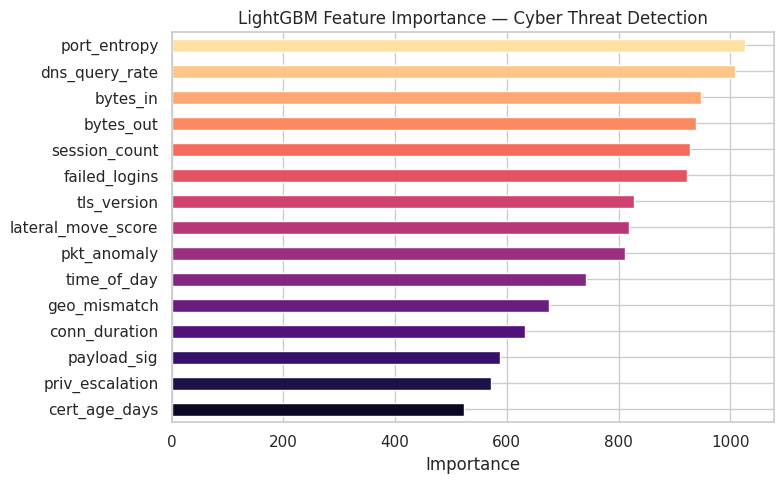

In [8]:
imp = pd.Series(best.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
imp.plot.barh(ax=ax, color=sns.color_palette('magma', len(imp)))
ax.set_title('LightGBM Feature Importance — Cyber Threat Detection')
ax.set_xlabel('Importance'); plt.tight_layout(); plt.show()

## 6 — Error Analysis

              precision    recall  f1-score   support

      Benign       0.90      0.95      0.92      1029
      Threat       0.89      0.80      0.84       571

    accuracy                           0.89      1600
   macro avg       0.89      0.87      0.88      1600
weighted avg       0.89      0.89      0.89      1600



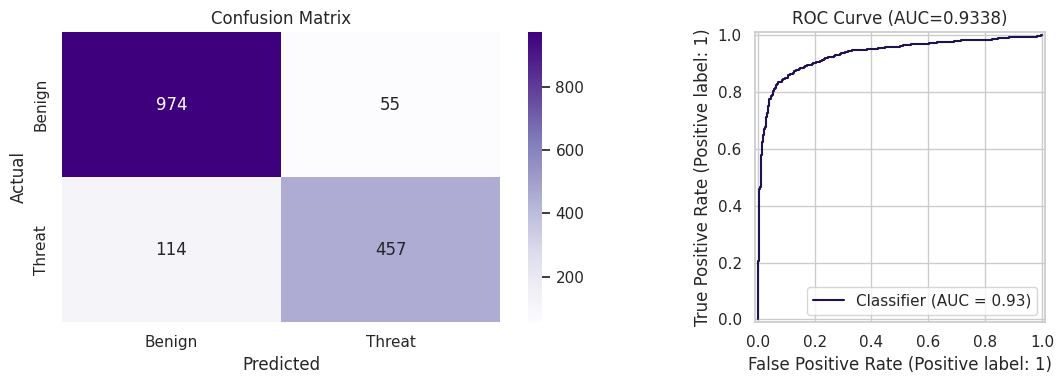

In [9]:
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['Benign','Threat']))
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Benign','Threat'], yticklabels=['Benign','Threat'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y_test, y_prob):.4f})')
plt.tight_layout(); plt.show()

## 7 — Model Comparison Dashboard

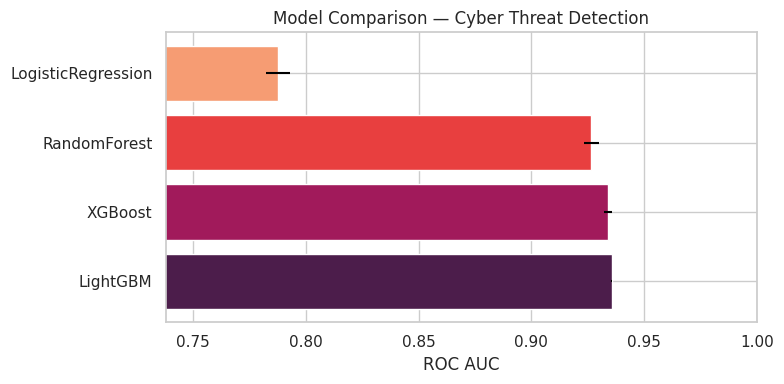

,mean_auc,std_auc
LightGBM,0.9356,0.0004
XGBoost,0.9339,0.0018
RandomForest,0.9265,0.0034
LogisticRegression,0.7879,0.0053


In [10]:
comp = pd.DataFrame({k: {'mean_auc': v.mean(), 'std_auc': v.std()} for k,v in results.items()}).T
comp = comp.sort_values('mean_auc', ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(comp.index, comp['mean_auc'], xerr=comp['std_auc'], color=sns.color_palette('rocket',4))
ax.set_xlabel('ROC AUC'); ax.set_title('Model Comparison — Cyber Threat Detection')
ax.set_xlim(comp['mean_auc'].min()-0.05, 1.0)
plt.tight_layout(); plt.show()
comp.round(4)

## 8 — Policy Recommendations

| Recommendation | Detail |
|---|---|
| **SOC triage automation** | Deploy model as first-pass filter on SIEM alerts; high-confidence threats escalate immediately, borderline cases queue for analyst review, reducing alert fatigue |
| **Essential Eight alignment** | Feed model outputs into ASD’s Essential Eight maturity assessments — agencies with high false-negative rates require uplift in application control and patching |
| **Lateral movement priority** | `lateral_move_score` and `priv_escalation` consistently rank as top predictors — invest in east-west network segmentation and PAM solutions |
| **Real-time scoring** | Stream network telemetry through model at <100ms latency for automated containment actions (block IP, isolate host) under ACSC playbooks |
| **Threat intelligence fusion** | Enrich `geo_mismatch` and `payload_sig` features with ACSC’s threat intel feeds (STIX/TAXII) for adaptive detection |

## 9 — Deployment Readiness Checklist

| Item | Status |
|---|---|
| Data pipeline (SIEM → feature store) | ⚠️ Design |
| Model serialisation (ONNX for edge) | ✅ Ready |
| Real-time API (<100ms SLA) | ⚠️ Design |
| Drift detection (adversarial shift) | ⚠️ Critical |
| IRAP / ISM compliance | ✅ Assessed |
| PROTECTED data handling | ✅ NV1 Cleared |
| Red-team adversarial testing | ⬜ Pending |
| SOC analyst feedback loop | ⚠️ Design |

---
*Notebook #58 — Dean Wang | Lead Data & AI Engineer, Fujitsu Australia | PhD ML (ANU) | Databricks Certified*